In [44]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import accuracy_score , classification_report, confusion_matrix, roc_curve, roc_auc_score,ConfusionMatrixDisplay

import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv(r'C:\Users\SuNi\Downloads\heart_disease_uci.csv')
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [2]:
print(df.shape)
df.info()

(920, 16)
<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    str    
 3   dataset   920 non-null    str    
 4   cp        920 non-null    str    
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    str    
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    str    
 13  ca        309 non-null    float64
 14  thal      434 non-null    str    
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(2), str(6)
memory usage: 156.4+ KB


In [3]:
df.describe()

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


In [4]:
df.isnull().sum()

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

In [45]:
df['HeartDisease'] = (df['num'] > 0 ).astype(int)
df = df.drop(['id', 'dataset', 'num'], axis=1)
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,HeartDisease
0,63,Male,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,67,Male,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,1
2,67,Male,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,37,Male,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,41,Female,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


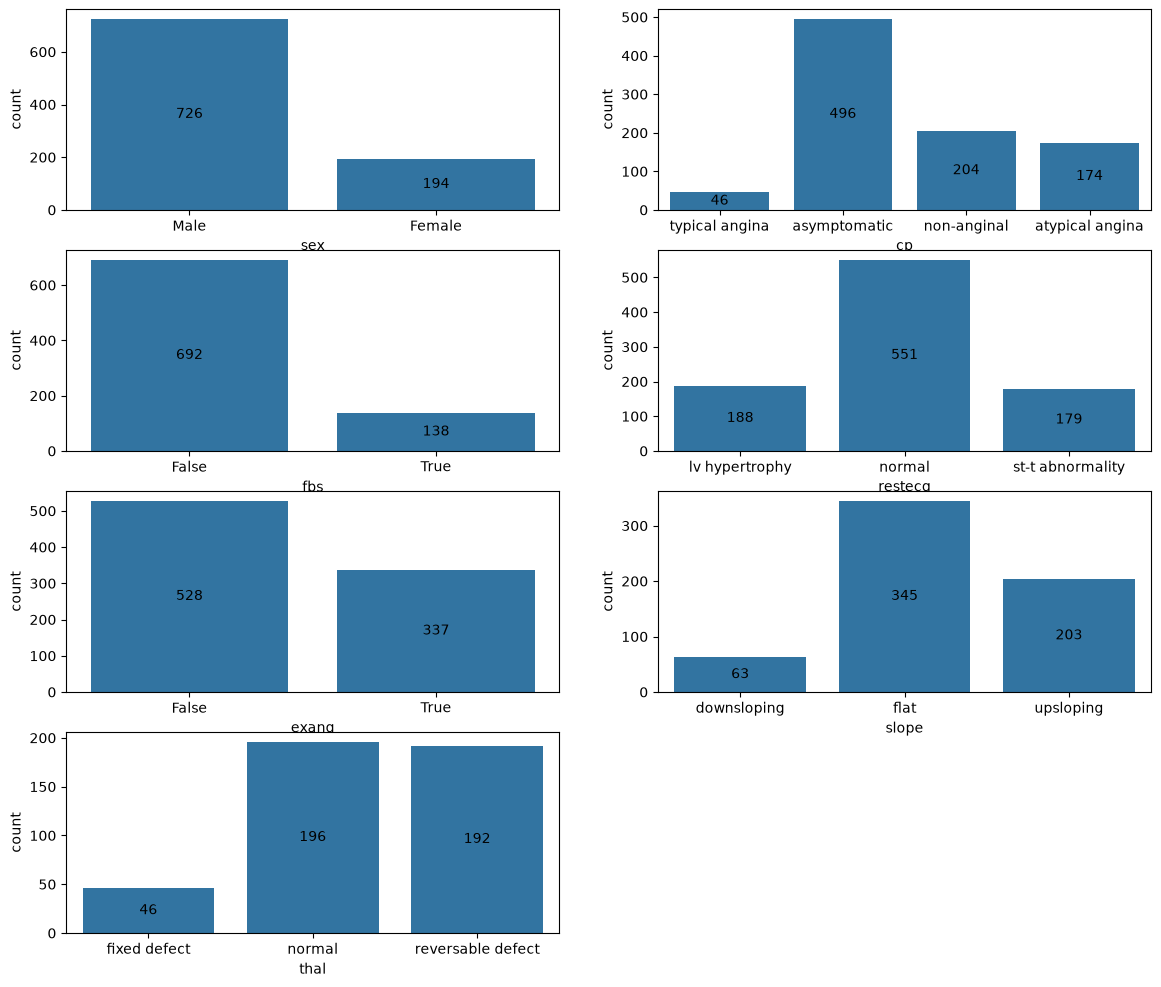

In [46]:
word_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']

plt.figure(figsize=(14, 12))
for idx, col in enumerate(word_cols):
    ax = plt.subplot(4, 2, idx+1)
    sns.countplot(x=df[col], ax=ax)
    for container in ax.containers:
        ax.bar_label(container, label_type='center')

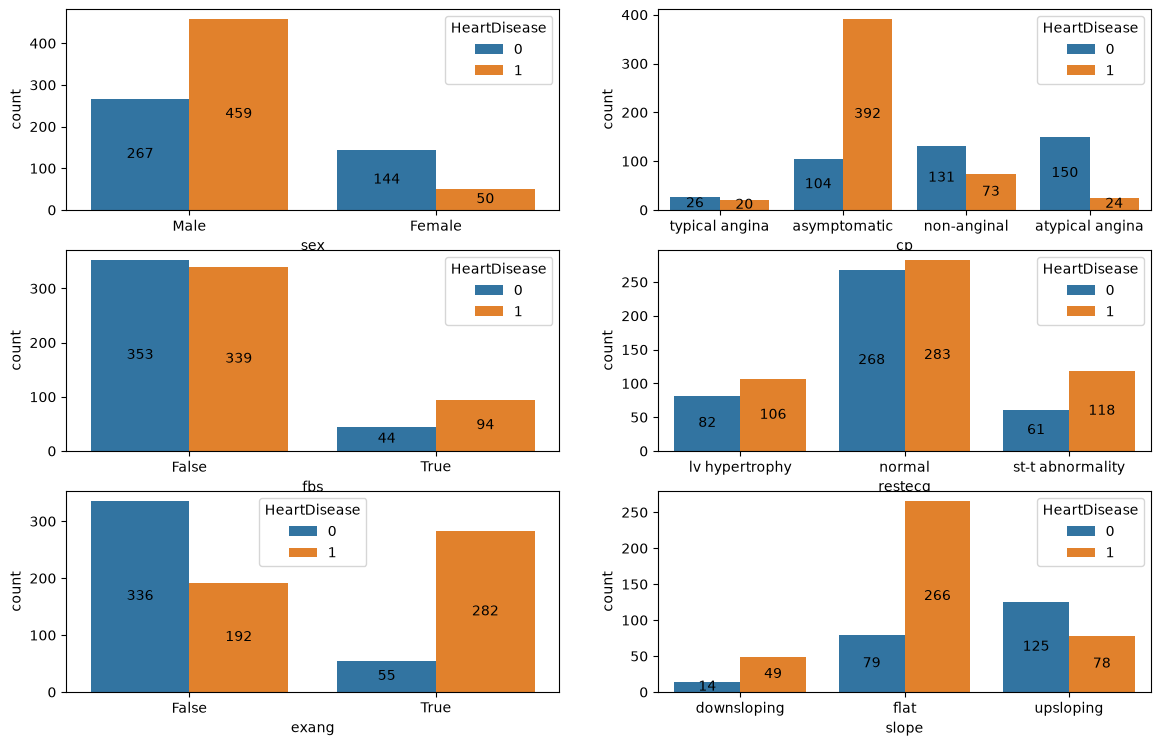

In [7]:
plt.figure(figsize=(14, 12))
for idx, col in enumerate(word_cols[:-1]):
    ax = plt.subplot(4, 2, idx+1)
    sns.countplot(x=df[col], hue=df['HeartDisease'], ax=ax)
    for container in ax.containers:
        ax.bar_label(container, label_type='center')

In [47]:
num_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']
word_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())
for col in word_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

le = LabelEncoder()
for col in word_cols:
    df[col] = le.fit_transform(df[col])
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,HeartDisease
0,63,1,3,145.0,233.0,1,0,150.0,0,2.3,0,0.0,0,0
1,67,1,0,160.0,286.0,0,0,108.0,1,1.5,1,3.0,1,1
2,67,1,0,120.0,229.0,0,0,129.0,1,2.6,1,2.0,2,1
3,37,1,2,130.0,250.0,0,1,187.0,0,3.5,0,0.0,1,0
4,41,0,1,130.0,204.0,0,0,172.0,0,1.4,2,0.0,1,0


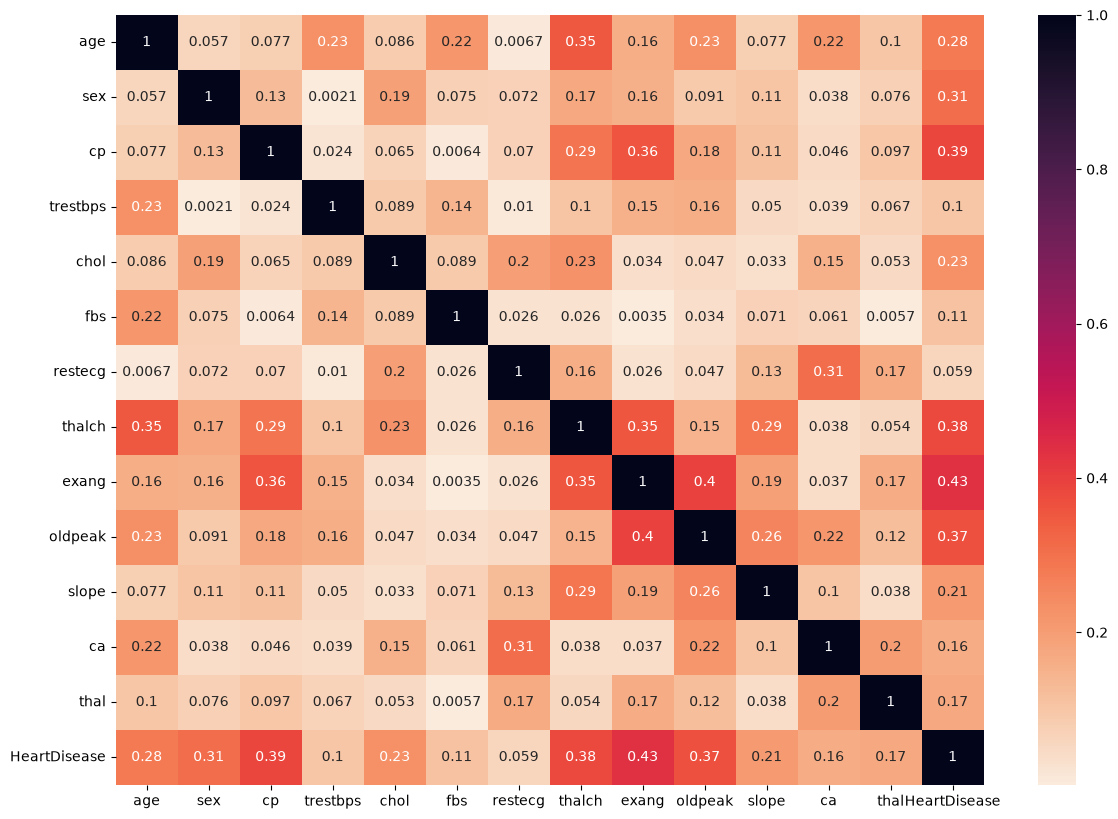

In [48]:
plt.figure(figsize=(14, 10))
corr = abs(df.corr())
sns.heatmap(corr, annot=True, cmap='rocket_r')
plt.show()

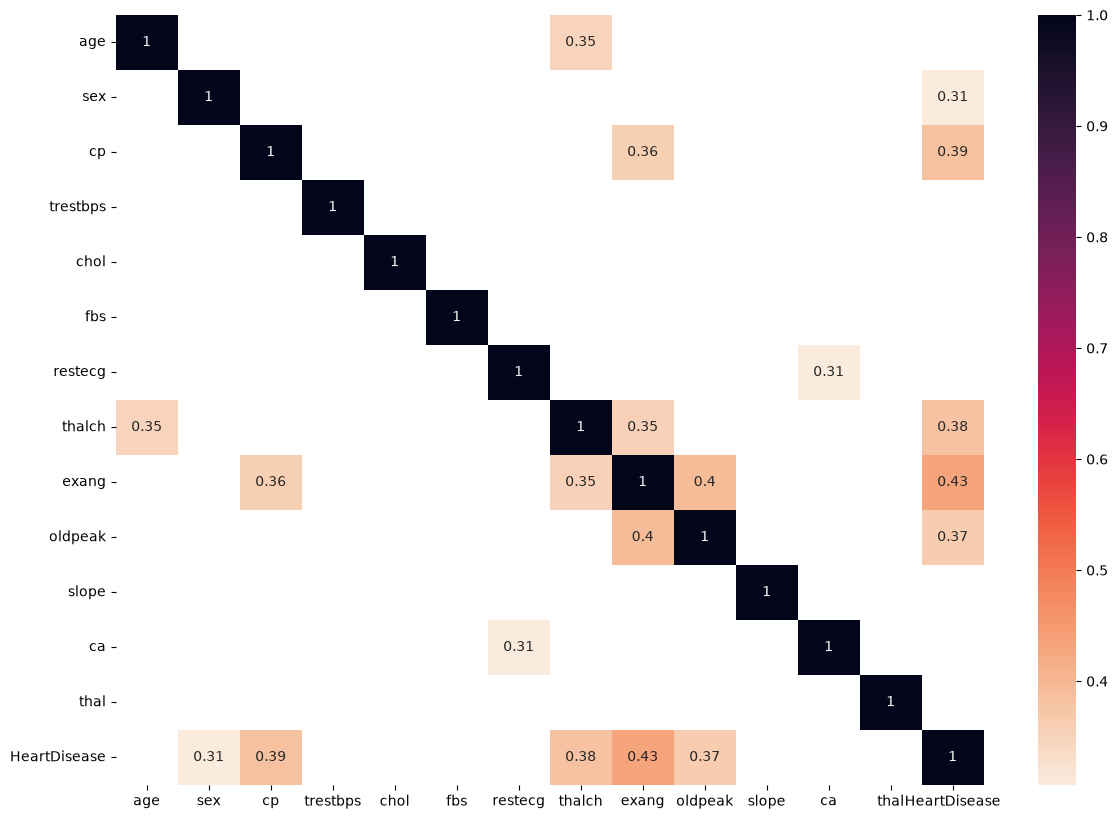

In [10]:
plt.figure(figsize=(14, 10))
sns.heatmap(corr[corr > 0.30], annot=True, cmap='rocket_r')
plt.show()

In [49]:
X = df.drop(['HeartDisease'], axis=1)
y = df['HeartDisease']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
acc = knn.score(X_val, y_val)
print(f"The KNN Classifiers trained with an accuracy {acc*100:.2f}%")

The KNN Classifiers trained with an accuracy 69.57%


In [50]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

knn = KNeighborsClassifier()
knn.fit(X_train_scaled, y_train)
accuracy = knn.score(X_val_scaled, y_val)
print(f'Accuracy Score: {accuracy*100:.2f}')

Accuracy Score: 78.80


In [51]:
X = df.drop(['HeartDisease'], axis=1)
y = df['HeartDisease']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_train

array([[0.69387755, 1.        , 0.        , ..., 0.5       , 0.        ,
        0.5       ],
       [0.53061224, 1.        , 0.66666667, ..., 0.5       , 0.        ,
        0.5       ],
       [0.46938776, 1.        , 0.66666667, ..., 0.5       , 0.        ,
        0.5       ],
       ...,
       [0.95918367, 1.        , 0.        , ..., 0.        , 0.        ,
        1.        ],
       [0.51020408, 0.        , 0.33333333, ..., 0.5       , 0.        ,
        0.5       ],
       [0.59183673, 0.        , 0.        , ..., 1.        , 0.33333333,
        0.5       ]], shape=(736, 13))

In [52]:
grid_params = {'n_neighbors': range(1, 21), 'metric': ['minkowski', 'manhattan']}

knn = KNeighborsClassifier()
knn_grid = GridSearchCV(knn, grid_params, scoring='accuracy')
knn_grid.fit(X_train, y_train)

knn_grid.best_score_*100, knn_grid.best_params_

(np.float64(80.711527854385), {'metric': 'manhattan', 'n_neighbors': 11})

In [53]:
X_test = scaler.transform(X_test)
predicts = knn_grid.best_estimator_.predict(X_test)
predicts_proba = knn_grid.best_estimator_.predict_proba(X_test)[:,1]

accuracy = accuracy_score(y_test, predicts)
print(f'Model Accuracy Score on test set: {accuracy*100:.2f}')

classi = classification_report(y_test, predicts)
print(f'Model Precision Score on test set:\n{classi}')

Model Accuracy Score on test set: 83.15
Model Precision Score on test set:
              precision    recall  f1-score   support

           0       0.76      0.85      0.81        75
           1       0.89      0.82      0.85       109

    accuracy                           0.83       184
   macro avg       0.83      0.83      0.83       184
weighted avg       0.84      0.83      0.83       184



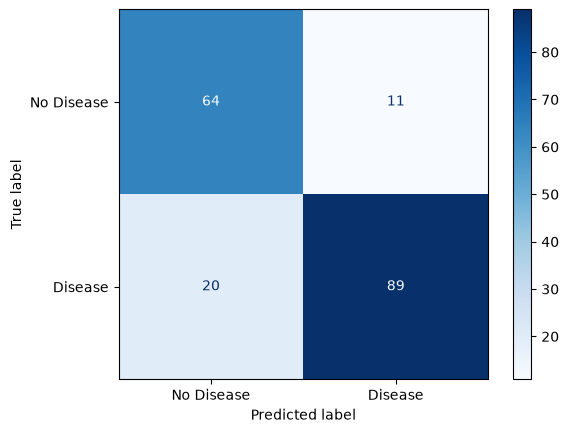

In [54]:
cm = confusion_matrix(y_test, predicts)
ConfusionMatrixDisplay(cm, display_labels=['No Disease', 'Disease']).plot(cmap='Blues')
plt.show()

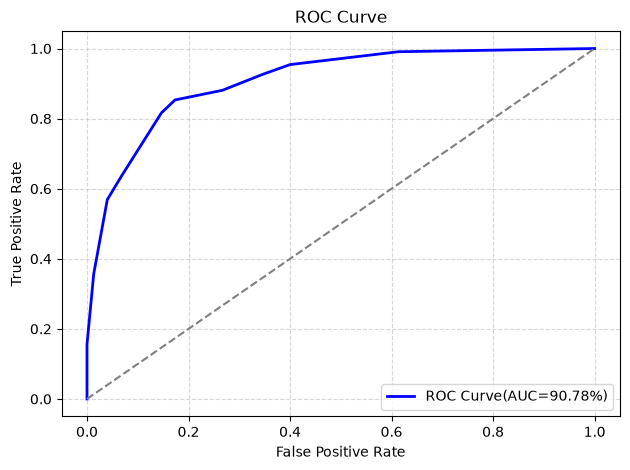

In [55]:
fpr, tpr,_ = roc_curve(y_test, predicts_proba)
auc_score = roc_auc_score(y_test, predicts_proba)

plt.plot(fpr, tpr, color ='blue', lw =2, label=f'ROC Curve(AUC={auc_score*100:.2f}%)')
plt.plot([0,1], [0,1], color='grey', linestyle='--')
plt.grid(True, linestyle='--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()